<a href="https://colab.research.google.com/github/SandraVargasAI/Mineria-de-Datos-/blob/main/MD_S6_Clustering_Laboratorio_Ejercicios_(SV).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Instalación (descomentar si es necesario)
# !pip install scikit-learn minisom matplotlib seaborn pandas numpy

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

from sklearn.datasets import make_blobs, make_moons, make_circles
from sklearn.cluster import KMeans, DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.decomposition import PCA

plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

np.random.seed(42)
print('✅ Librerías cargadas correctamente')

✅ Librerías cargadas correctamente


### 🔬 Ejercicio S1
> **Calculá las distancias entre los siguientes vectores y analizá cuál métrica es más apropiada:**
> - `a = [3, 0, 4, 0, 2]`
> - `b = [1, 1, 1, 1, 1]`
> - `c = [6, 0, 8, 0, 4]`  ← ¿notás algo con la distancia coseno respecto a `a`?
>
> Pensá: si estos vectores representaran **frecuencias de palabras** en documentos,  
> ¿qué métrica usarías para agruparlos?

# Calculá las distancias entre los siguientes vectores y analizá cuál métrica es más apropiada

=== Distancias entre a y b ===
  Euclidiana : 4.0000
  Manhattan  : 8.0000
  Coseno     : 0.2526

=== Distancias entre a y c ===
  Euclidiana : 5.3852  ← muy diferente
  Manhattan  : 9.0000  ← muy diferente
  Coseno     : 0.0000  ← similar dirección!


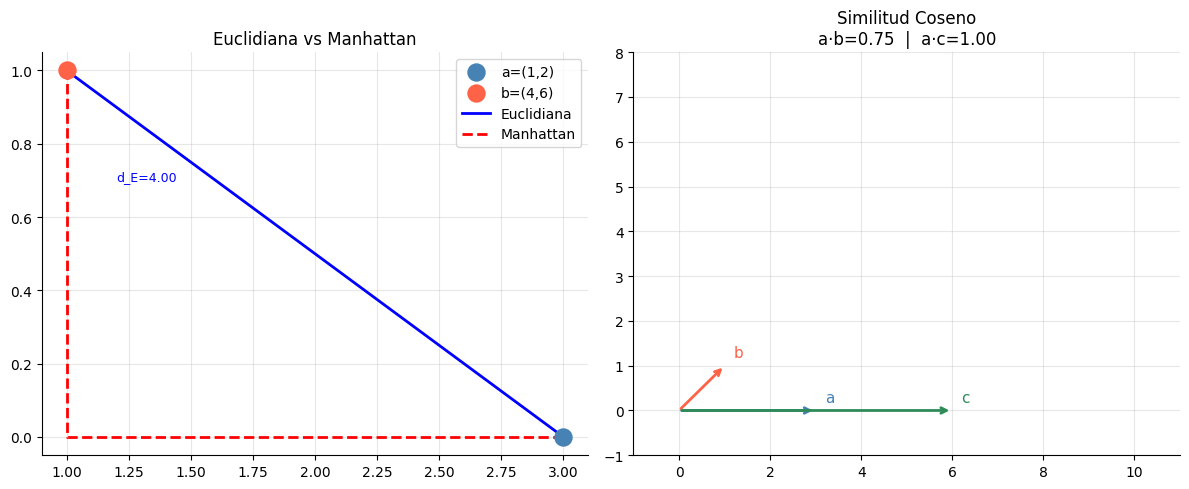

In [ ]:
# Tu código aquí
import numpy as np
import matplotlib.pyplot as plt

a = np.array([3, 0, 4, 0, 2])
b = np.array([1, 1, 1, 1, 1])
c = np.array([6, 0, 8, 0, 4])

# Calculá las tres métricas entre cada par
# Tip: usá euclidean(), cityblock(), cosine() de scipy.spatial.distance
from scipy.spatial.distance import euclidean, cityblock, cosine

print('=== Distancias entre a y b ===')
print(f'  Euclidiana : {euclidean(a, b):.4f}')
print(f'  Manhattan  : {cityblock(a, b):.4f}')
print(f'  Coseno     : {cosine(a, b):.4f}')

print('\n=== Distancias entre a y c ===')
print(f'  Euclidiana : {euclidean(a, c):.4f}  ← muy diferente')
print(f'  Manhattan  : {cityblock(a, c):.4f}  ← muy diferente')
print(f'  Coseno     : {cosine(a, c):.4f}  ← similar dirección!')

# Visualización
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Euclidiana vs Manhattan
ax = axes[0]
# Changed *a to a[0], a[1] to explicitly plot the first two dimensions
ax.scatter(a[0], a[1], color='steelblue', s=150, zorder=5, label='a=(1,2)')
# Changed *b to b[0], b[1] to explicitly plot the first two dimensions
ax.scatter(b[0], b[1], color='tomato', s=150, zorder=5, label='b=(4,6)')
ax.plot([a[0], b[0]], [a[1], b[1]], 'b-', lw=2, label='Euclidiana')
ax.plot([a[0], b[0], b[0]], [a[1], a[1], b[1]], 'r--', lw=2, label='Manhattan')
ax.legend(); ax.set_title('Euclidiana vs Manhattan'); ax.grid(alpha=0.3)
ax.text((a[0]+b[0])/2-0.8, (a[1]+b[1])/2+0.2,
        f'd_E={euclidean(a,b):.2f}', color='blue', fontsize=9)

# Similitud coseno
ax2 = axes[1]
origin = [0, 0]
vecs = {'a': (a, 'steelblue'), 'b': (b, 'tomato'), 'c': (c, 'seagreen')}
for name, (v, color) in vecs.items():
    # Changed xy=v to xy=(v[0], v[1]) to explicitly plot the first two dimensions
    ax2.annotate('', xy=(v[0], v[1]), xytext=origin,
                 arrowprops=dict(arrowstyle='->', color=color, lw=2))
    ax2.text(v[0]+0.2, v[1]+0.2, name, color=color, fontsize=11)
ax2.set_xlim(-1, 11); ax2.set_ylim(-1, 8)
# Changed p3 to c
ax2.set_title(f'Similitud Coseno\na·b={1-cosine(a,b):.2f}  |  a·c={1-cosine(a,c):.2f}')
ax2.grid(alpha=0.3)
plt.tight_layout(); plt.show()

# **Respuesta**

Puede observaser que el vector c es exactamente igual al doble del vector a, ambos apuntan en la misma dirección. Aunque a y c tienen el mismo patrón, la distancia euclidiana los considera distintos porque cambia la magnitud. La métrica coseno interpreta que ambos vectores son “idénticos” en comportamiento, aunque uno tenga valores más grandes.



# **falta.... verificar**
¿Qué métrica usar para documentos?

Si los vectores representan frecuencias de palabras en documentos, la mejor opción suele ser la distancia coseno.

¿Por qué?

Dos documentos pueden tener diferente longitud,
pero compartir el mismo patrón de palabras.
La similitud coseno se enfoca en la proporción y no en la cantidad total de palabras.

Por eso, en minería de texto, NLP y recomendación de documentos, la métrica coseno es una de las más utilizadas para clustering y búsqueda de similitud.

### 🔬 Ejercicio S2
> 1. Usá el dataset `X_noisy` (con outliers). Aplicá K-Means con k=3 y visualizá el resultado.
> 2. ¿El resultado parece correcto? ¿Los outliers afectan los centroides?
> 3. Calculá el Silhouette Score y compará con el resultado en `X_blobs`.
> 4. **Bonus:** Probá aplicar `StandardScaler` antes de K-Means. ¿Cambia el resultado?

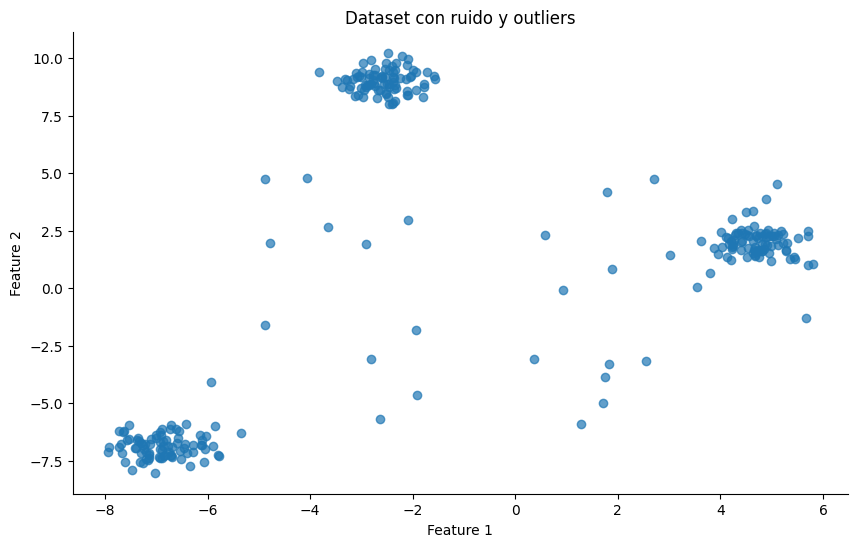

In [ ]:
# Tu código aquí
# Tip: scaler = StandardScaler()
# X_scaled = scaler.fit_transform(X_noisy)

# Dataset 4: Con ruido y outliers (ideal para DBSCAN)
X_noisy, y_noisy = make_blobs(n_samples=250, centers=3,
                               cluster_std=0.5, random_state=42)
noise = np.random.uniform(-6, 6, size=(30, 2))

X_noisy = np.vstack([X_noisy, noise])

# Escalar los datos
scaler = StandardScaler()
X_noisy_scaled = scaler.fit_transform(X_noisy)

# K-Means
kmeans = KMeans(n_clusters=3, init='k-means++', n_init=10, random_state=42)
labels_km = kmeans.fit_predict(X_noisy_scaled)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Gráfico del dataset X_noisy (con outliers)
plt.scatter(X_noisy[:, 0], X_noisy[:, 1], cmap="viridis", alpha=0.7)
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Dataset con ruido y outliers")
plt.show()

#